# 4. Clustering Model Comparison

This notebook compares K-Means, Agglomerative Clustering, and DBSCAN in the complete PCA space produced by notebook 03. Candidate configurations are evaluated with internal validation metrics, cluster balance, noise coverage, and perturbation stability.

### Responsibilities

- Load and validate PCA scores.
- Search candidate configurations for three clustering families.
- Evaluate cohesion, separation, balance, coverage, and stability.
- Select and refit the strongest eligible candidate.
- Persist candidate results, selected labels, diagnostics, and the model.

### Out of Scope

Business interpretation, cluster naming, and detailed engagement profiling are handled by notebook 05.

## 4.1. Environment and Library Imports

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn joblib tqdm -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Standard library imports
from pathlib import Path
import sys

# Third-party imports
import joblib
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import (
    AgglomerativeClustering,
    DBSCAN,
    KMeans,
)
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
    silhouette_score,
)
from sklearn.neighbors import NearestNeighbors
from tqdm.auto import tqdm

In [3]:
current_directory = Path.cwd().resolve()
project_candidates = (current_directory, *current_directory.parents)

PROJECT_ROOT = next(
    (path for path in project_candidates if (path / "src").is_dir()),
    None,
)

if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root directory.")

SRC_DIRECTORY = PROJECT_ROOT / "src"

if str(SRC_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SRC_DIRECTORY))

### 4.1.1. Custom Utilities

In [4]:
from data_collection_utils import save_dataframe_csv
from data_preprocessing_utils import validate_numeric_matrix

## 4.2. Configuration

Search ranges and eligibility rules are centralized so the comparison can be reproduced and adjusted explicitly.

In [5]:
PCA_DATA_PATH = (
    PROJECT_ROOT / "data" / "processed" / "facebook_posts_pca.csv"
)
CANDIDATE_RESULTS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "clustering_candidate_results.csv"
)
MODEL_COMPARISON_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "clustering_model_comparison.csv"
)
SELECTED_LABELS_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "selected_cluster_labels.csv"
)
SELECTED_MODEL_PATH = (
    PROJECT_ROOT / "artifacts" / "selected_clustering_model.joblib"
)
FIGURES_DIRECTORY = PROJECT_ROOT / "reports" / "figures"

RECORD_ID_COLUMN = "record_id"
RANDOM_STATE = 42
K_VALUES = range(2, 16)
SILHOUETTE_SAMPLE_SIZE = 2_000
MIN_CLUSTER_SIZE = 50
MAX_CLUSTER_SHARE = 0.90
MIN_DBSCAN_COVERAGE = 0.80
MIN_STABILITY_ARI = 0.80
PERTURBATION_COUNT = 5
PERTURBATION_SCALE = 0.01
DBSCAN_MIN_SAMPLES_VALUES = [5, 10, 20, 50]
EPS_QUANTILES = [0.80, 0.85, 0.90, 0.95, 0.97, 0.99]
AGGLOMERATIVE_CONFIGURATIONS = [
    ("ward", "euclidean"),
    ("complete", "euclidean"),
    ("complete", "manhattan"),
    ("average", "euclidean"),
    ("average", "manhattan"),
    ("average", "cosine"),
]

## 4.3. PCA Data Loading and Validation

Clustering is performed in the complete selected PCA space. The first two components are reserved for visualization only.

In [6]:
if not PCA_DATA_PATH.exists():
    raise FileNotFoundError(
        "PCA dataset not found. Run "
        "03_dimensionality_reduction.ipynb first."
    )

pca_data = pd.read_csv(PCA_DATA_PATH)

if RECORD_ID_COLUMN not in pca_data.columns:
    raise ValueError(
        f"Required identifier column not found: {RECORD_ID_COLUMN}"
    )

record_ids = pca_data[RECORD_ID_COLUMN].copy()
pca_features = validate_numeric_matrix(
    pca_data,
    excluded_columns=[RECORD_ID_COLUMN],
)

if record_ids.duplicated().any():
    raise ValueError("Duplicated record identifiers found.")

print(f"PCA data loaded from: {PCA_DATA_PATH}")
print(f"Observations: {len(pca_features):,}")
print(f"PCA components: {pca_features.shape[1]}")

PCA data loaded from: C:\Projetos\facebook_clusterizacao\data\processed\facebook_posts_pca.csv
Observations: 7,050
PCA components: 10


## 4.4. Evaluation Policy

Silhouette and Calinski-Harabasz scores are maximized, while Davies-Bouldin is minimized. Eligibility also requires a minimum cluster size, prevents a single dominant cluster, and enforces sufficient non-noise coverage for DBSCAN. DBSCAN metrics are calculated only on non-noise observations; noise is reported separately.

In [7]:
def sampled_silhouette_score(
    features: pd.DataFrame | np.ndarray,
    labels: np.ndarray,
) -> float:
    """Calculate a reproducible sampled Silhouette Score."""
    sample_size = min(SILHOUETTE_SAMPLE_SIZE, len(features))

    return float(
        silhouette_score(
            features,
            labels,
            sample_size=sample_size,
            random_state=RANDOM_STATE,
        )
    )

In [8]:
def evaluate_clustering(
    features: pd.DataFrame | np.ndarray,
    labels: np.ndarray,
    *,
    algorithm: str,
    parameters: dict,
) -> dict:
    """Evaluate clustering quality, balance, coverage, and eligibility."""
    feature_values = np.asarray(features)
    labels = np.asarray(labels)
    noise_mask = labels == -1
    evaluation_mask = ~noise_mask
    evaluated_features = feature_values[evaluation_mask]
    evaluated_labels = labels[evaluation_mask]
    cluster_count = len(np.unique(evaluated_labels))

    result = {
        "algorithm": algorithm,
        "cluster_count": cluster_count,
        "noise_count": int(noise_mask.sum()),
        "noise_share": float(noise_mask.mean()),
        "coverage": float(evaluation_mask.mean()),
        "silhouette_score": np.nan,
        "calinski_harabasz_score": np.nan,
        "davies_bouldin_score": np.nan,
        "minimum_cluster_size": np.nan,
        "maximum_cluster_share": np.nan,
        "eligible": False,
        **parameters,
    }

    if cluster_count < 2 or cluster_count >= len(evaluated_labels):
        return result

    cluster_sizes = pd.Series(evaluated_labels).value_counts()
    result.update(
        {
            "silhouette_score": sampled_silhouette_score(
                evaluated_features,
                evaluated_labels,
            ),
            "calinski_harabasz_score": float(
                calinski_harabasz_score(
                    evaluated_features,
                    evaluated_labels,
                )
            ),
            "davies_bouldin_score": float(
                davies_bouldin_score(
                    evaluated_features,
                    evaluated_labels,
                )
            ),
            "minimum_cluster_size": int(cluster_sizes.min()),
            "maximum_cluster_share": float(
                cluster_sizes.max() / cluster_sizes.sum()
            ),
        }
    )
    result["eligible"] = (
        result["minimum_cluster_size"] >= MIN_CLUSTER_SIZE
        and result["maximum_cluster_share"] <= MAX_CLUSTER_SHARE
        and (
            algorithm != "DBSCAN"
            or result["coverage"] >= MIN_DBSCAN_COVERAGE
        )
    )

    return result

## 4.5. K-Means Search

Inertia is recorded for within-family diagnostics but is not compared with metrics from other clustering algorithms.

In [9]:
kmeans_results = []

for cluster_count in tqdm(K_VALUES, desc="Evaluating K-Means"):
    model = KMeans(
        n_clusters=cluster_count,
        n_init=20,
        random_state=RANDOM_STATE,
    )
    labels = model.fit_predict(pca_features)
    result = evaluate_clustering(
        pca_features,
        labels,
        algorithm="K-Means",
        parameters={
            "n_clusters": cluster_count,
            "linkage": None,
            "metric": "euclidean",
            "eps": np.nan,
            "min_samples": np.nan,
            "inertia": float(model.inertia_),
        },
    )
    kmeans_results.append(result)

kmeans_results = pd.DataFrame(kmeans_results)
display(kmeans_results)

Evaluating K-Means:   0%|          | 0/14 [00:00<?, ?it/s]

,algorithm,cluster_count,noise_count,noise_share,coverage,silhouette_score,calinski_harabasz_score,davies_bouldin_score,minimum_cluster_size,maximum_cluster_share,eligible,n_clusters,linkage,metric,eps,min_samples,inertia
0,K-Means,2,0,0.0,1.0,0.361583,2515.523268,1.359126,1251,0.822553,True,2,None,euclidean,NaN,NaN,70782.584741
1,K-Means,3,0,0.0,1.0,0.135432,1756.037986,2.073280,1198,0.481135,True,3,None,euclidean,NaN,NaN,64099.865559
2,K-Means,4,0,0.0,1.0,0.148819,1478.297690,1.970500,361,0.469362,True,4,None,euclidean,NaN,NaN,58944.787690
3,K-Means,5,0,0.0,1.0,0.137999,1345.211514,1.902117,328,0.320567,True,5,None,euclidean,NaN,NaN,54454.479537
4,K-Means,6,0,0.0,1.0,0.144592,1246.450641,1.808769,290,0.269220,True,6,None,euclidean,NaN,NaN,50959.341628
5,K-Means,7,0,0.0,1.0,0.145171,1164.293800,1.755786,289,0.195035,True,7,None,euclidean,NaN,NaN,48218.862615
6,K-Means,8,0,0.0,1.0,0.150362,1093.914496,1.647462,112,0.191206,True,8,None,euclidean,NaN,NaN,46012.475054
7,K-Means,9,0,0.0,1.0,0.154650,1042.115265,1.631221,110,0.165532,True,9,None,euclidean,NaN,NaN,43976.261098
8,K-Means,10,0,0.0,1.0,0.153995,987.951173,1.671873,110,0.162837,True,10,None,euclidean,NaN,NaN,42441.700999
9,K-Means,11,0,0.0,1.0,0.154383,947.421146,1.697239,108,0.162837,True,11,None,euclidean,NaN,NaN,40940.945096


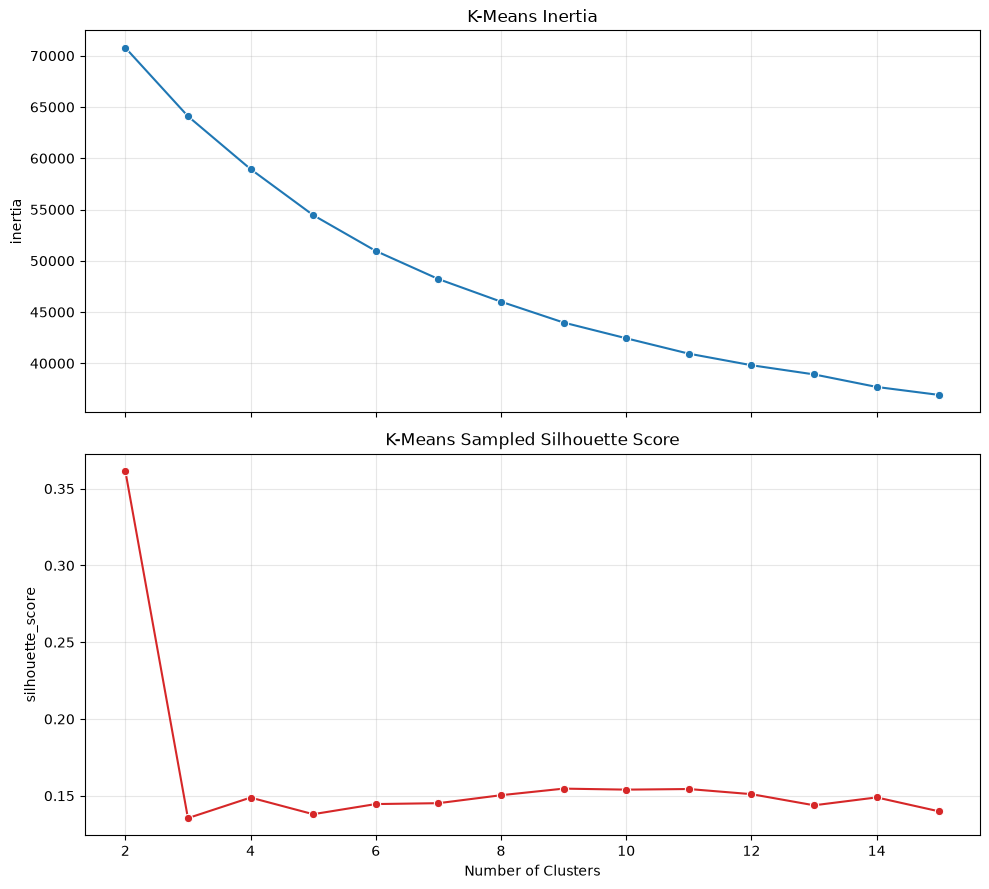

In [10]:
FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharex=True)
sns.lineplot(
    data=kmeans_results,
    x="n_clusters",
    y="inertia",
    marker="o",
    ax=axes[0],
)
sns.lineplot(
    data=kmeans_results,
    x="n_clusters",
    y="silhouette_score",
    marker="o",
    color="tab:red",
    ax=axes[1],
)
axes[0].set_title("K-Means Inertia")
axes[1].set_title("K-Means Sampled Silhouette Score")
axes[1].set_xlabel("Number of Clusters")

for axis in axes:
    axis.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(
    FIGURES_DIRECTORY / "kmeans_search_diagnostics.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 4.6. Agglomerative Clustering Search

Ward, complete, and average linkage configurations are compared. Single linkage is omitted because its chaining behavior commonly produces poorly balanced solutions in this type of data.

In [11]:
agglomerative_results = []
search_space = [
    (cluster_count, linkage, metric)
    for cluster_count in K_VALUES
    for linkage, metric in AGGLOMERATIVE_CONFIGURATIONS
]

for cluster_count, linkage, metric in tqdm(
    search_space,
    desc="Evaluating Agglomerative Clustering",
):
    model = AgglomerativeClustering(
        n_clusters=cluster_count,
        linkage=linkage,
        metric=metric,
    )
    labels = model.fit_predict(pca_features)
    result = evaluate_clustering(
        pca_features,
        labels,
        algorithm="Agglomerative Clustering",
        parameters={
            "n_clusters": cluster_count,
            "linkage": linkage,
            "metric": metric,
            "eps": np.nan,
            "min_samples": np.nan,
            "inertia": np.nan,
        },
    )
    agglomerative_results.append(result)

agglomerative_results = pd.DataFrame(agglomerative_results)
display(
    agglomerative_results.sort_values(
        "silhouette_score",
        ascending=False,
    ).head(10)
)

Evaluating Agglomerative Clustering:   0%|          | 0/84 [00:00<?, ?it/s]

,algorithm,cluster_count,noise_count,noise_share,coverage,silhouette_score,calinski_harabasz_score,davies_bouldin_score,minimum_cluster_size,maximum_cluster_share,eligible,n_clusters,linkage,metric,eps,min_samples,inertia
4,Agglomerative Clustering,2,0,0.0,1.0,0.626881,65.399503,0.698828,7,0.999007,False,2,average,manhattan,NaN,NaN,NaN
3,Agglomerative Clustering,2,0,0.0,1.0,0.529382,602.066451,0.746872,89,0.987376,False,2,average,euclidean,NaN,NaN,NaN
1,Agglomerative Clustering,2,0,0.0,1.0,0.514315,753.159490,0.968927,139,0.980284,False,2,complete,euclidean,NaN,NaN,NaN
7,Agglomerative Clustering,3,0,0.0,1.0,0.492890,424.693926,0.969357,19,0.980284,False,3,complete,euclidean,NaN,NaN,NaN
9,Agglomerative Clustering,3,0,0.0,1.0,0.483221,362.360651,1.060781,26,0.983688,False,3,average,euclidean,NaN,NaN,NaN
10,Agglomerative Clustering,3,0,0.0,1.0,0.467408,76.846769,0.912989,7,0.996312,False,3,average,manhattan,NaN,NaN,NaN
15,Agglomerative Clustering,4,0,0.0,1.0,0.461910,245.269918,0.996561,3,0.983688,False,4,average,euclidean,NaN,NaN,NaN
13,Agglomerative Clustering,4,0,0.0,1.0,0.457954,313.733789,0.903343,14,0.978298,False,4,complete,euclidean,NaN,NaN,NaN
19,Agglomerative Clustering,5,0,0.0,1.0,0.449569,249.019371,1.129126,14,0.978298,False,5,complete,euclidean,NaN,NaN,NaN
2,Agglomerative Clustering,2,0,0.0,1.0,0.411626,753.773891,1.539090,326,0.953759,False,2,complete,manhattan,NaN,NaN,NaN


## 4.7. DBSCAN Search

Candidate `eps` values are derived from nearest-neighbor distance quantiles instead of an arbitrary fixed interval.

In [12]:
dbscan_results = []

for min_samples in tqdm(
    DBSCAN_MIN_SAMPLES_VALUES,
    desc="Evaluating DBSCAN neighborhoods",
):
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors.fit(pca_features)
    distances, _ = neighbors.kneighbors(pca_features)
    neighbor_distances = distances[:, -1]
    eps_candidates = np.unique(
        np.quantile(neighbor_distances, EPS_QUANTILES)
    )

    for eps in eps_candidates:
        model = DBSCAN(
            eps=float(eps),
            min_samples=min_samples,
        )
        labels = model.fit_predict(pca_features)
        result = evaluate_clustering(
            pca_features,
            labels,
            algorithm="DBSCAN",
            parameters={
                "n_clusters": np.nan,
                "linkage": None,
                "metric": "euclidean",
                "eps": float(eps),
                "min_samples": min_samples,
                "inertia": np.nan,
            },
        )
        dbscan_results.append(result)

dbscan_results = pd.DataFrame(dbscan_results)
display(
    dbscan_results.sort_values(
        "silhouette_score",
        ascending=False,
    ).head(10)
)

Evaluating DBSCAN neighborhoods:   0%|          | 0/4 [00:00<?, ?it/s]

,algorithm,cluster_count,noise_count,noise_share,coverage,silhouette_score,calinski_harabasz_score,davies_bouldin_score,minimum_cluster_size,maximum_cluster_share,eligible,n_clusters,linkage,metric,eps,min_samples,inertia
5,DBSCAN,2,44,0.006241,0.993759,0.486929,16.785586,0.796344,5.0,0.999286,False,NaN,None,euclidean,3.000083,5,NaN
3,DBSCAN,4,195,0.027660,0.972340,0.448932,37.411804,0.740919,4.0,0.996353,False,NaN,None,euclidean,2.174595,5,NaN
14,DBSCAN,2,391,0.055461,0.944539,0.372087,51.382051,0.758605,13.0,0.998048,False,NaN,None,euclidean,2.426824,20,NaN
7,DBSCAN,5,752,0.106667,0.893333,0.266330,43.381537,1.115673,10.0,0.991426,False,NaN,None,euclidean,1.829802,10,NaN
2,DBSCAN,15,467,0.066241,0.933759,0.213929,62.459948,1.165965,4.0,0.965669,False,NaN,None,euclidean,1.787632,5,NaN
8,DBSCAN,7,378,0.053617,0.946383,0.144760,60.398609,1.036816,7.0,0.989508,False,NaN,None,euclidean,2.120033,10,NaN
1,DBSCAN,20,753,0.106809,0.893191,0.120946,35.309287,0.988162,3.0,0.974432,False,NaN,None,euclidean,1.565550,5,NaN
0,DBSCAN,17,1008,0.142979,0.857021,-0.050538,20.488140,0.911923,2.0,0.986428,False,NaN,None,euclidean,1.420045,5,NaN
4,DBSCAN,1,109,0.015461,0.984539,NaN,NaN,NaN,NaN,NaN,False,NaN,None,euclidean,2.471298,5,NaN
6,DBSCAN,1,949,0.134610,0.865390,NaN,NaN,NaN,NaN,NaN,False,NaN,None,euclidean,1.635646,10,NaN


## 4.8. Candidate Consolidation

Only eligible candidates participate in family-level selection. This prevents a high Silhouette Score from masking tiny clusters, a dominant cluster, or excessive DBSCAN noise.

In [13]:
candidate_results = pd.concat(
    [kmeans_results, agglomerative_results, dbscan_results],
    ignore_index=True,
)
eligible_candidates = candidate_results[
    candidate_results["eligible"]
].copy()

if eligible_candidates.empty:
    raise RuntimeError(
        "No candidate satisfies the configured eligibility rules."
    )

family_best_candidates = (
    eligible_candidates.sort_values(
        [
            "silhouette_score",
            "calinski_harabasz_score",
            "davies_bouldin_score",
        ],
        ascending=[False, False, True],
    )
    .groupby("algorithm", as_index=False)
    .first()
)

display(family_best_candidates)

,algorithm,cluster_count,noise_count,noise_share,coverage,silhouette_score,calinski_harabasz_score,davies_bouldin_score,minimum_cluster_size,maximum_cluster_share,eligible,n_clusters,linkage,metric,eps,min_samples,inertia
0,Agglomerative Clustering,2,0,0.0,1.0,0.364350,2346.167398,1.341639,1137.0,0.838723,True,2.0,ward,euclidean,NaN,NaN,NaN
1,K-Means,2,0,0.0,1.0,0.361583,2515.523268,1.359126,1251.0,0.822553,True,2.0,None,euclidean,NaN,NaN,70782.584741


## 4.9. Perturbation Stability

The best candidate from each family is refitted after small feature-wise Gaussian perturbations. Adjusted Rand Index compares each perturbed solution with its original labels.

In [14]:
def build_candidate_model(
    candidate: pd.Series,
) -> KMeans | AgglomerativeClustering | DBSCAN:
    """Instantiate a clustering model from a candidate-result row."""
    algorithm = candidate["algorithm"]

    if algorithm == "K-Means":
        return KMeans(
            n_clusters=int(candidate["n_clusters"]),
            n_init=20,
            random_state=RANDOM_STATE,
        )

    if algorithm == "Agglomerative Clustering":
        return AgglomerativeClustering(
            n_clusters=int(candidate["n_clusters"]),
            linkage=candidate["linkage"],
            metric=candidate["metric"],
        )

    if algorithm == "DBSCAN":
        return DBSCAN(
            eps=float(candidate["eps"]),
            min_samples=int(candidate["min_samples"]),
        )

    raise ValueError(f"Unsupported algorithm: {algorithm}")

In [15]:
def evaluate_candidate_stability(
    candidate: pd.Series,
    features: pd.DataFrame,
) -> tuple[float, float]:
    """Return mean and standard deviation of perturbation ARI."""
    feature_values = features.to_numpy()
    baseline_model = build_candidate_model(candidate)
    baseline_labels = baseline_model.fit_predict(feature_values)
    feature_scale = feature_values.std(axis=0, ddof=0)
    feature_scale = np.where(feature_scale == 0, 1.0, feature_scale)
    rng = np.random.default_rng(RANDOM_STATE)
    stability_scores = []

    for _ in range(PERTURBATION_COUNT):
        perturbation = rng.normal(
            loc=0.0,
            scale=PERTURBATION_SCALE * feature_scale,
            size=feature_values.shape,
        )
        perturbed_model = build_candidate_model(candidate)
        perturbed_labels = perturbed_model.fit_predict(
            feature_values + perturbation
        )
        stability_scores.append(
            adjusted_rand_score(baseline_labels, perturbed_labels)
        )

    return (
        float(np.mean(stability_scores)),
        float(np.std(stability_scores, ddof=0)),
    )

In [16]:
stability_means = []
stability_stds = []

for _, candidate in tqdm(
    family_best_candidates.iterrows(),
    total=len(family_best_candidates),
    desc="Evaluating stability",
):
    stability_mean, stability_std = evaluate_candidate_stability(
        candidate,
        pca_features,
    )
    stability_means.append(stability_mean)
    stability_stds.append(stability_std)

family_best_candidates["stability_ari_mean"] = stability_means
family_best_candidates["stability_ari_std"] = stability_stds
family_best_candidates["stable"] = (
    family_best_candidates["stability_ari_mean"] >= MIN_STABILITY_ARI
)

display(family_best_candidates)

Evaluating stability:   0%|          | 0/2 [00:00<?, ?it/s]

,algorithm,cluster_count,noise_count,noise_share,coverage,silhouette_score,calinski_harabasz_score,davies_bouldin_score,minimum_cluster_size,maximum_cluster_share,eligible,n_clusters,linkage,metric,eps,min_samples,inertia,stability_ari_mean,stability_ari_std,stable
0,Agglomerative Clustering,2,0,0.0,1.0,0.364350,2346.167398,1.341639,1137.0,0.838723,True,2.0,ward,euclidean,NaN,NaN,NaN,0.967094,0.014120,True
1,K-Means,2,0,0.0,1.0,0.361583,2515.523268,1.359126,1251.0,0.822553,True,2.0,None,euclidean,NaN,NaN,70782.584741,0.996156,0.001273,True


## 4.10. Final Model Selection

Stable family winners are preferred. If none reaches the configured ARI threshold, the selection falls back to the eligible family winners and preserves the stability result as a limitation.

In [17]:
stable_candidates = family_best_candidates[
    family_best_candidates["stable"]
]
selection_pool = (
    stable_candidates
    if not stable_candidates.empty
    else family_best_candidates
)
selected_candidate = (
    selection_pool.sort_values(
        [
            "silhouette_score",
            "calinski_harabasz_score",
            "davies_bouldin_score",
        ],
        ascending=[False, False, True],
    )
    .iloc[0]
)

family_best_candidates["selected"] = (
    family_best_candidates["algorithm"]
    == selected_candidate["algorithm"]
)

display(family_best_candidates)
print(f"Selected algorithm: {selected_candidate['algorithm']}")

,algorithm,cluster_count,noise_count,noise_share,coverage,silhouette_score,calinski_harabasz_score,davies_bouldin_score,minimum_cluster_size,maximum_cluster_share,...,n_clusters,linkage,metric,eps,min_samples,inertia,stability_ari_mean,stability_ari_std,stable,selected
0,Agglomerative Clustering,2,0,0.0,1.0,0.364350,2346.167398,1.341639,1137.0,0.838723,...,2.0,ward,euclidean,NaN,NaN,NaN,0.967094,0.014120,True,True
1,K-Means,2,0,0.0,1.0,0.361583,2515.523268,1.359126,1251.0,0.822553,...,2.0,None,euclidean,NaN,NaN,70782.584741,0.996156,0.001273,True,False


Selected algorithm: Agglomerative Clustering


In [18]:
selected_model = build_candidate_model(selected_candidate)
selected_labels = selected_model.fit_predict(pca_features)
selected_evaluation = evaluate_clustering(
    pca_features,
    selected_labels,
    algorithm=selected_candidate["algorithm"],
    parameters={},
)

selected_cluster_labels = pd.DataFrame(
    {
        RECORD_ID_COLUMN: record_ids.to_numpy(),
        "cluster": selected_labels,
    }
)

display(pd.Series(selected_evaluation, name="value").to_frame())

,value
algorithm,Agglomerative Clustering
cluster_count,2
noise_count,0
noise_share,0.0
coverage,1.0
silhouette_score,0.36435
calinski_harabasz_score,2346.167398
davies_bouldin_score,1.341639
minimum_cluster_size,1137
maximum_cluster_share,0.838723


## 4.11. Comparison and Selected-Model Diagnostics

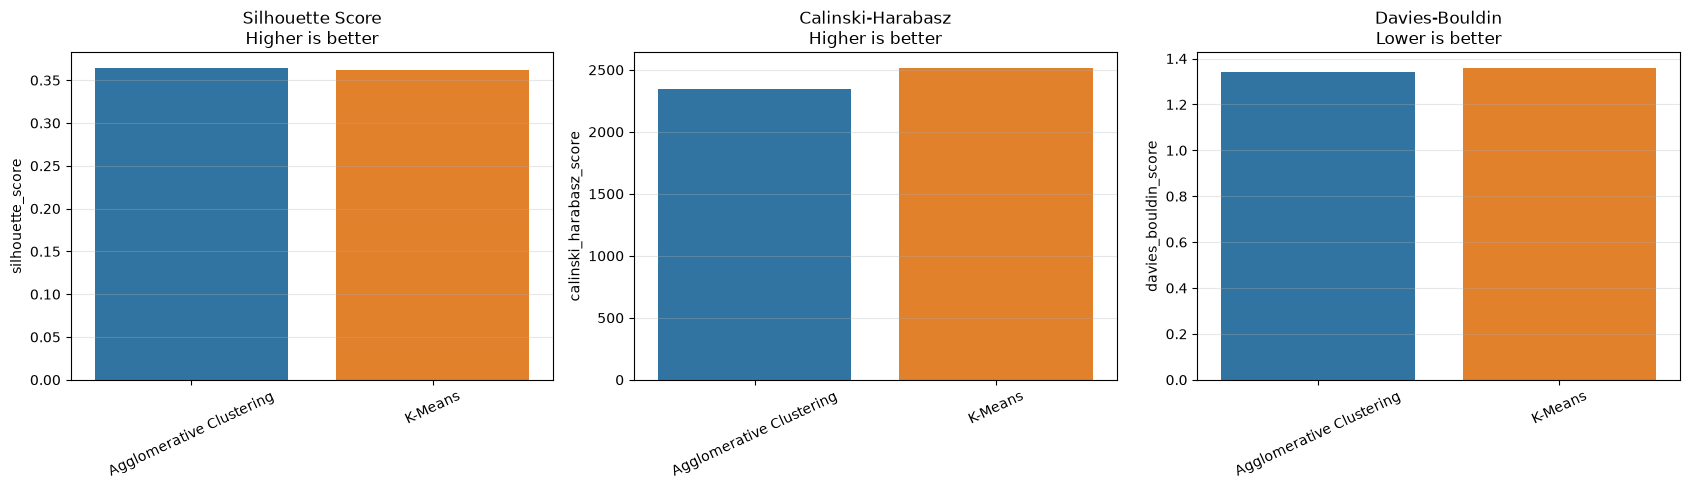

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
metric_configuration = [
    ("silhouette_score", "Silhouette Score", False),
    ("calinski_harabasz_score", "Calinski-Harabasz", False),
    ("davies_bouldin_score", "Davies-Bouldin", True),
]

for axis, (metric, title, lower_is_better) in zip(
    axes,
    metric_configuration,
):
    sns.barplot(
        data=family_best_candidates,
        x="algorithm",
        y=metric,
        hue="algorithm",
        legend=False,
        ax=axis,
    )
    direction = "Lower is better" if lower_is_better else "Higher is better"
    axis.set_title(f"{title}\n{direction}")
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=25)
    axis.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(
    FIGURES_DIRECTORY / "clustering_model_comparison.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

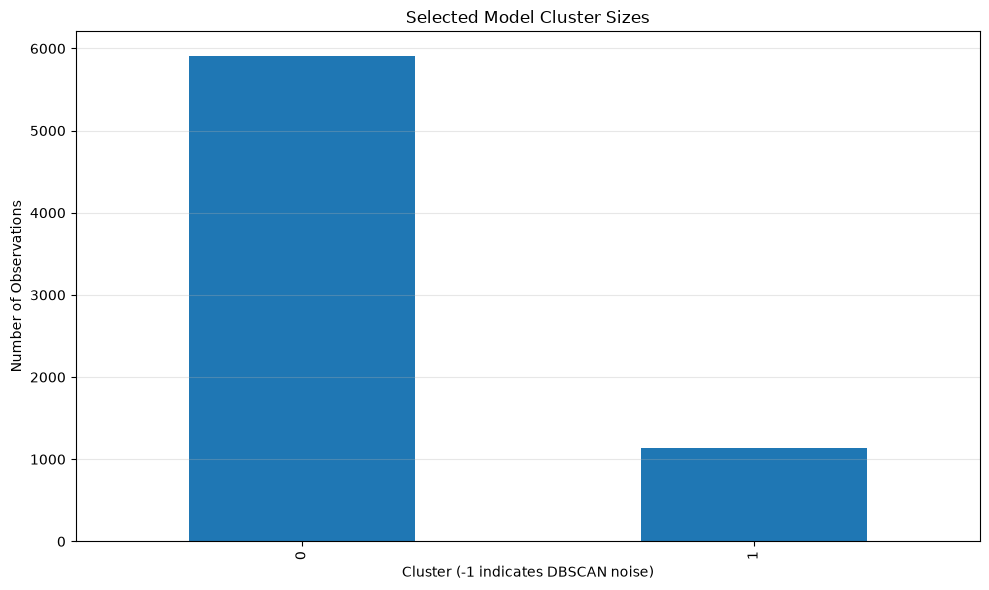

In [20]:
cluster_sizes = (
    selected_cluster_labels["cluster"].value_counts().sort_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
cluster_sizes.plot(kind="bar", ax=ax)
ax.set(
    title="Selected Model Cluster Sizes",
    xlabel="Cluster (-1 indicates DBSCAN noise)",
    ylabel="Number of Observations",
)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(
    FIGURES_DIRECTORY / "selected_cluster_sizes.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

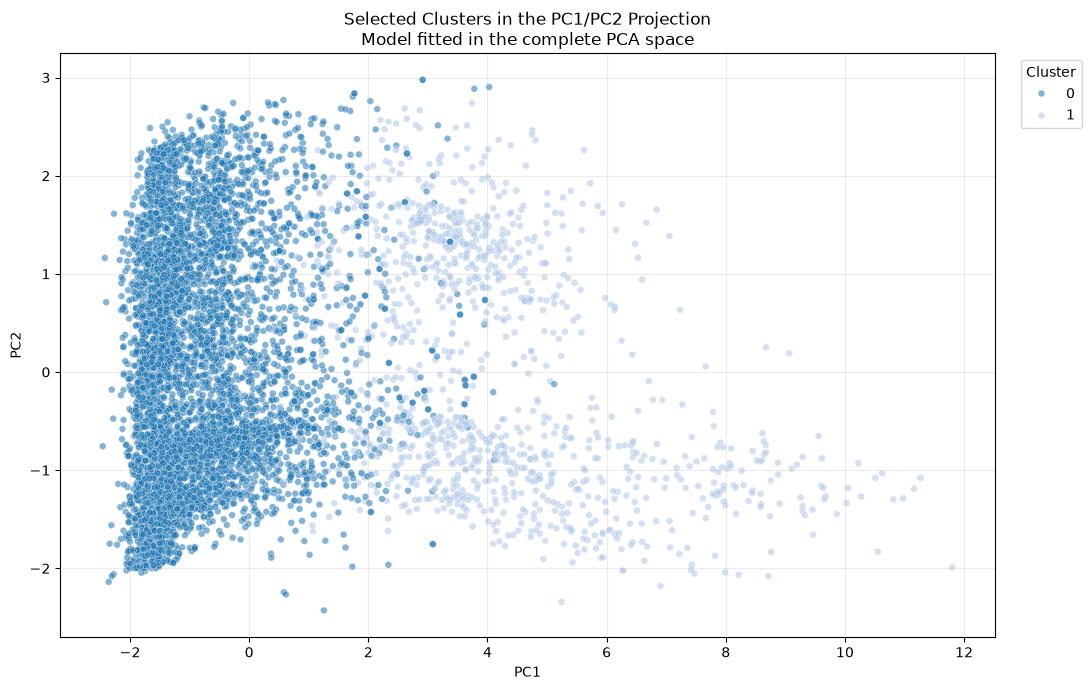

In [21]:
projection = pca_data[[RECORD_ID_COLUMN, "PC1", "PC2"]].copy()
projection["cluster"] = selected_labels

fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(
    data=projection,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="tab20",
    alpha=0.55,
    s=24,
    ax=ax,
)
ax.set_title(
    "Selected Clusters in the PC1/PC2 Projection\n"
    "Model fitted in the complete PCA space"
)
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(
    FIGURES_DIRECTORY / "selected_clusters_pca_projection.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

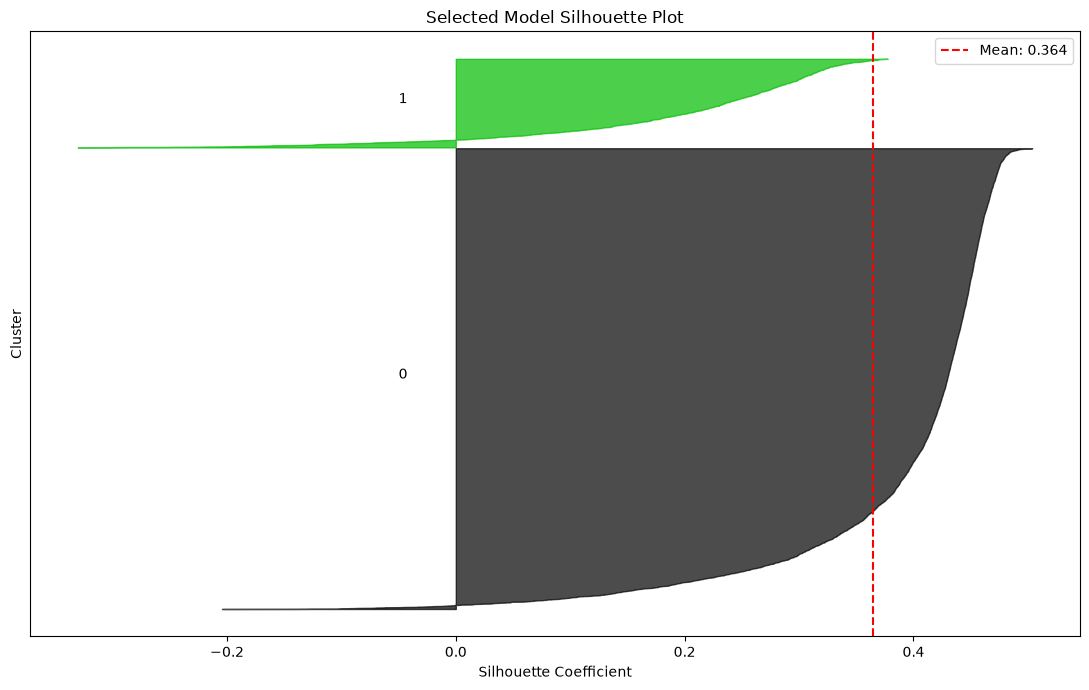

In [22]:
noise_mask = selected_labels == -1
silhouette_features = pca_features.loc[~noise_mask]
silhouette_labels = selected_labels[~noise_mask]
silhouette_values = silhouette_samples(
    silhouette_features,
    silhouette_labels,
)
silhouette_average = silhouette_score(
    silhouette_features,
    silhouette_labels,
)
unique_clusters = np.unique(silhouette_labels)

fig, ax = plt.subplots(figsize=(11, 7))
y_lower = 10

for position, cluster in enumerate(unique_clusters):
    cluster_values = silhouette_values[
        silhouette_labels == cluster
    ]
    cluster_values.sort()
    y_upper = y_lower + len(cluster_values)
    color = cm.nipy_spectral(position / len(unique_clusters))
    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )
    ax.text(-0.05, y_lower + len(cluster_values) / 2, str(cluster))
    y_lower = y_upper + 10

ax.axvline(
    silhouette_average,
    color="red",
    linestyle="--",
    label=f"Mean: {silhouette_average:.3f}",
)
ax.set(
    title="Selected Model Silhouette Plot",
    xlabel="Silhouette Coefficient",
    ylabel="Cluster",
)
ax.set_yticks([])
ax.legend()

fig.tight_layout()
fig.savefig(
    FIGURES_DIRECTORY / "selected_model_silhouette.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 4.12. Output Validation and Persistence

In [23]:
if len(selected_cluster_labels) != len(pca_data):
    raise ValueError("Selected labels and PCA data have different lengths.")

if not selected_cluster_labels[RECORD_ID_COLUMN].equals(record_ids):
    raise ValueError("Record identifiers are not aligned.")

if selected_cluster_labels["cluster"].isna().any():
    raise ValueError("Missing cluster labels found.")

family_best_candidates["supports_predict"] = (
    family_best_candidates["algorithm"] == "K-Means"
)

candidate_results_path = save_dataframe_csv(
    candidate_results,
    CANDIDATE_RESULTS_PATH,
)
model_comparison_path = save_dataframe_csv(
    family_best_candidates,
    MODEL_COMPARISON_PATH,
)
selected_labels_path = save_dataframe_csv(
    selected_cluster_labels,
    SELECTED_LABELS_PATH,
)

SELECTED_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(selected_model, SELECTED_MODEL_PATH)

print(f"Candidate results saved to: {candidate_results_path}")
print(f"Model comparison saved to: {model_comparison_path}")
print(f"Selected labels saved to: {selected_labels_path}")
print(f"Selected model saved to: {SELECTED_MODEL_PATH}")

Candidate results saved to: C:\Projetos\facebook_clusterizacao\data\processed\clustering_candidate_results.csv
Model comparison saved to: C:\Projetos\facebook_clusterizacao\data\processed\clustering_model_comparison.csv
Selected labels saved to: C:\Projetos\facebook_clusterizacao\data\processed\selected_cluster_labels.csv
Selected model saved to: C:\Projetos\facebook_clusterizacao\artifacts\selected_clustering_model.joblib


## 4.13. Clustering Model Comparison Summary

- K-Means, Agglomerative Clustering, and DBSCAN were evaluated in the complete selected PCA space.
- Candidate configurations were compared using internal validation metrics, cluster balance, noise coverage, and perturbation stability.
- DBSCAN noise points were excluded from internal metric calculations and reported separately.
- Configurations with very small or dominant clusters were marked as ineligible.
- The selected model was refitted on the complete PCA dataset.
- Candidate results, family winners, selected labels, diagnostics, and the fitted estimator were persisted.

If Agglomerative Clustering or DBSCAN is selected, the persisted estimator does not provide conventional out-of-sample `predict()` behavior. In that case, the saved labels are the primary result for this dataset.

### Handoff to Notebook 05

Notebook `05_cluster_analysis_and_conclusions.ipynb` should join `selected_cluster_labels.csv` with `facebook_posts_cleaned.csv` through `record_id`. It is responsible for cluster profiles, engagement comparisons, content-type and publication-time analysis, cluster naming, limitations, and business interpretation.

In [24]:
assert CANDIDATE_RESULTS_PATH.exists()
assert MODEL_COMPARISON_PATH.exists()
assert SELECTED_LABELS_PATH.exists()
assert SELECTED_MODEL_PATH.exists()

print("Clustering model comparison completed successfully.")

Clustering model comparison completed successfully.
